<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A: LINEAR REGRESSION

1. Creating synthetic regression dataset...
Training set size: 240 samples
Testing set size: 60 samples

2. Training Linear Regression model...

3. Model Performance Metrics:
----------------------------------------
Training MSE: 228.8446
Testing MSE: 240.0475
Training MAE: 12.1294
Testing MAE: 12.0117
Training R² Score: 0.7564
Testing R² Score: 0.7986

4. Model Coefficients:
----------------------------------------
Intercept (β₀): 0.3065
Coefficient (β₁): 27.6115

5. Interpretation:
----------------------------------------
• Intercept (β₀): Expected value of y when all features are 0
• Coefficient (β₁): For each unit increase in X, y increases by 27.6115


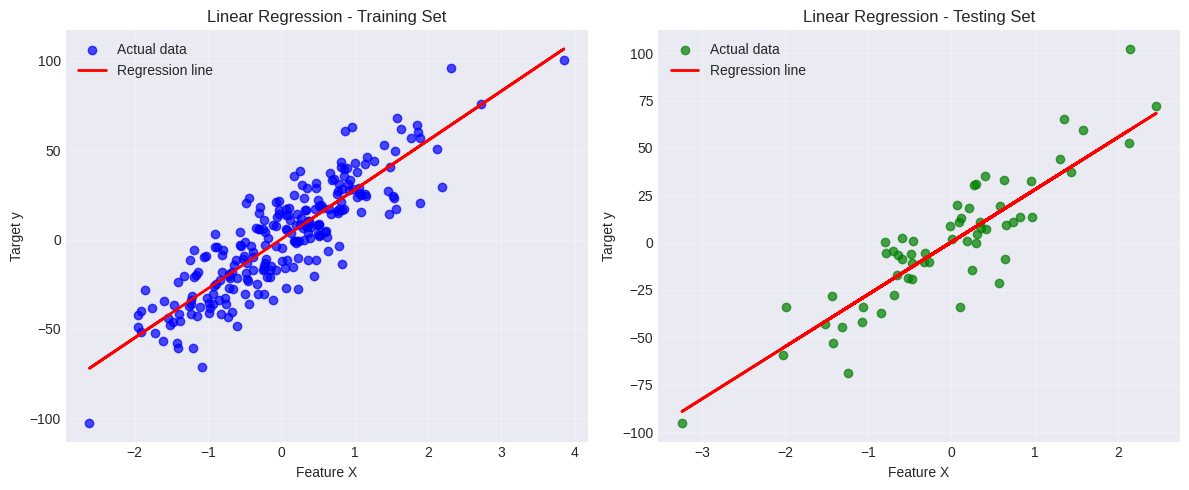


PART B: LOGISTIC REGRESSION

1. Loading Cancer dataset...
Dataset shape: (569, 30)
Number of features: 30
Classes: ['malignant' 'benign']
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...

Training set size: 398 samples
Testing set size: 171 samples
Class distribution in training set: [148 250]
Class distribution in testing set: [ 64 107]

2. Training Logistic Regression model...

3. Model Performance Metrics:
----------------------------------------
Training Accuracy: 0.9874
Testing Accuracy: 0.9883
Precision: 0.9907
Recall: 0.9907
F1-Score: 0.9907

4. Confusion Matrix:


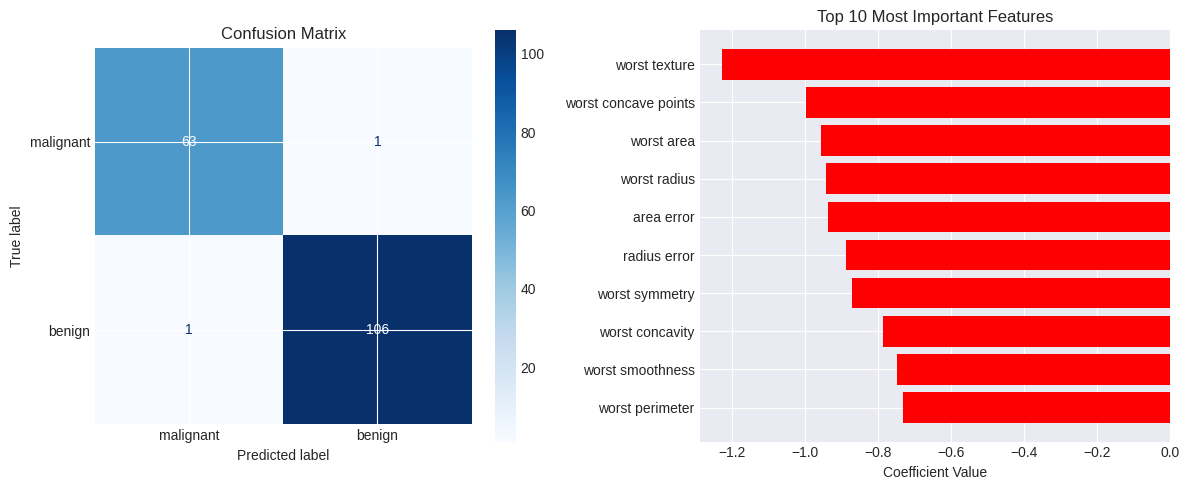


5. Top 10 Model Coefficients (Feature Importance):
----------------------------------------
worst texture             Coefficient:  -1.2263 (decreases probability of malignant)
worst concave points      Coefficient:  -0.9968 (decreases probability of malignant)
worst area                Coefficient:  -0.9550 (decreases probability of malignant)
worst radius              Coefficient:  -0.9411 (decreases probability of malignant)
area error                Coefficient:  -0.9375 (decreases probability of malignant)
radius error              Coefficient:  -0.8864 (decreases probability of malignant)
worst symmetry            Coefficient:  -0.8694 (decreases probability of malignant)
worst concavity           Coefficient:  -0.7860 (decreases probability of malignant)
worst smoothness          Coefficient:  -0.7490 (decreases probability of malignant)
worst perimeter           Coefficient:  -0.7310 (decreases probability of malignant)

6. Interpretation:
-------------------------------------

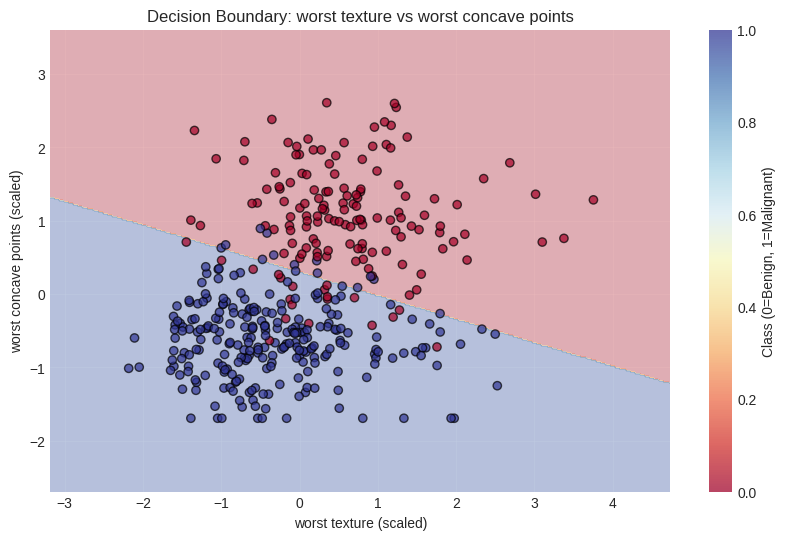


PROGRAM COMPLETED SUCCESSFULLY


In [1]:
# Experiment #4: IMPLEMENT LINEAR REGRESSION AND LOGISTIC REGRESSION MODELS
# Analyze coefficients, calculate performance metrics, and visualize results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================
#  PART A: LINEAR REGRESSION
# ============================
print("=" * 60)
print("PART A: LINEAR REGRESSION")
print("=" * 60)

# Create synthetic regression data
print("\n1. Creating synthetic regression dataset...")
X, y = make_regression(n_samples=300, n_features=1, noise=15, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Train linear regression model
print("\n2. Training Linear Regression model...")
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n3. Model Performance Metrics:")
print("-" * 40)
print(f"Training MSE: {mse_train:.4f}")
print(f"Testing MSE: {mse_test:.4f}")
print(f"Training MAE: {mae_train:.4f}")
print(f"Testing MAE: {mae_test:.4f}")
print(f"Training R² Score: {r2_train:.4f}")
print(f"Testing R² Score: {r2_test:.4f}")

# Print model coefficients
print("\n4. Model Coefficients:")
print("-" * 40)
print(f"Intercept (β₀): {linear_model.intercept_:.4f}")
print(f"Coefficient (β₁): {linear_model.coef_[0]:.4f}")

print("\n5. Interpretation:")
print("-" * 40)
print("• Intercept (β₀): Expected value of y when all features are 0")
print(f"• Coefficient (β₁): For each unit increase in X, y increases by {linear_model.coef_[0]:.4f}")

# Plot regression line vs actual data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set plot
axes[0].scatter(X_train, y_train, alpha=0.7, label="Actual data", color="blue")
axes[0].plot(X_train, y_train_pred, color="red", linewidth=2, label="Regression line")
axes[0].set_xlabel("Feature X")
axes[0].set_ylabel("Target y")
axes[0].set_title("Linear Regression - Training Set")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing set plot
axes[1].scatter(X_test, y_test, alpha=0.7, label="Actual data", color="green")
axes[1].plot(X_test, y_test_pred, color="red", linewidth=2, label="Regression line")
axes[1].set_xlabel("Feature X")
axes[1].set_ylabel("Target y")
axes[1].set_title("Linear Regression - Testing Set")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================
#  PART B: LOGISTIC REGRESSION
# ============================
print("\n" + "=" * 60)
print("PART B: LOGISTIC REGRESSION")
print("=" * 60)

# Load Cancer dataset
print("\n1. Loading Cancer dataset...")
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Classes: {data.target_names}")
print(f"Features: {data.feature_names[:5]}...")  # Show first 5 features

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in testing set: {np.bincount(y_test)}")

# Standardize features for better convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
print("\n2. Training Logistic Regression model...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = logistic_model.predict(X_train_scaled)
y_test_pred = logistic_model.predict(X_test_scaled)
y_test_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n3. Model Performance Metrics:")
print("-" * 40)
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Testing Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot confusion matrix + top coefficients
print("\n4. Confusion Matrix:")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

# Feature importance (top 10 coefficients)
feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": logistic_model.coef_[0]
})
feature_importance["Abs_Coefficient"] = np.abs(feature_importance["Coefficient"])
feature_importance = feature_importance.sort_values("Abs_Coefficient", ascending=False)

top_features = feature_importance.head(10)
colors = ["red" if x < 0 else "green" for x in top_features["Coefficient"]]
axes[1].barh(range(len(top_features)), top_features["Coefficient"], color=colors)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features["Feature"])
axes[1].set_xlabel("Coefficient Value")
axes[1].set_title("Top 10 Most Important Features")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Print top coefficients
print("\n5. Top 10 Model Coefficients (Feature Importance):")
print("-" * 40)
for _, row in top_features.iterrows():
    direction = "increases" if row["Coefficient"] > 0 else "decreases"
    print(f"{row['Feature']:25} Coefficient: {row['Coefficient']:8.4f} ({direction} probability of malignant)")

print("\n6. Interpretation:")
print("-" * 40)
print("• Positive coefficients increase probability of malignant class")
print("• Negative coefficients decrease probability of malignant class")
print("• Larger absolute values indicate stronger feature influence")
print(f"\nModel intercept: {logistic_model.intercept_[0]:.4f}")

# Visualize decision boundary (using two most important features)
print("\n7. Decision Boundary Visualization (using two most important features)...")
top_two_features = feature_importance.head(2)["Feature"].values

# Find indices of top two features
idx1 = np.where(data.feature_names == top_two_features[0])[0][0]
idx2 = np.where(data.feature_names == top_two_features[1])[0][0]

# Train new model with only two features for visualization
X_two_features = X[:, [idx1, idx2]]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_two_features, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize 2D features
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train model
model_2d = LogisticRegression(max_iter=1000, random_state=42)
model_2d.fit(X_train_2d_scaled, y_train_2d)

# Create mesh for decision boundary
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict for each point in mesh
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
scatter = plt.scatter(
    X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
    c=y_train_2d, cmap="RdYlBu", edgecolors="k", alpha=0.7
)

plt.xlabel(f"{top_two_features[0]} (scaled)")
plt.ylabel(f"{top_two_features[1]} (scaled)")
plt.title(f"Decision Boundary: {top_two_features[0]} vs {top_two_features[1]}")
plt.colorbar(scatter, label="Class (0=Benign, 1=Malignant)")
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 60)
print("PROGRAM COMPLETED SUCCESSFULLY")
print("=" * 60)

**POST LAB**

POST-LAB A: RIDGE & LASSO WITH DIFFERENT ALPHA VALUES

Linear Regression -> Test MSE: 350.6401589231058  Test R2: 0.7879750030803048

--- Ridge Results (alpha, MSE, R2) ---
alpha=0.01   MSE=350.6417 R2=0.7880
alpha=0.1    MSE=350.6561 R2=0.7880
alpha=1      MSE=350.8124 R2=0.7879
alpha=10     MSE=353.5910 R2=0.7862
alpha=100    MSE=446.6988 R2=0.7299

--- Lasso Results (alpha, MSE, R2) ---
alpha=0.01   MSE=350.6520 R2=0.7880
alpha=0.1    MSE=350.7664 R2=0.7879
alpha=1      MSE=352.6689 R2=0.7867
alpha=10     MSE=447.5853 R2=0.7294
alpha=100    MSE=1673.7264 R2=-0.0121

POST-LAB A: POLYNOMIAL REGRESSION VS LINEAR REGRESSION

--- Polynomial Results (degree, MSE, R2) ---
degree=2  MSE=349.9343 R2=0.7884
degree=3  MSE=351.2856 R2=0.7876
degree=5  MSE=349.0602 R2=0.7889


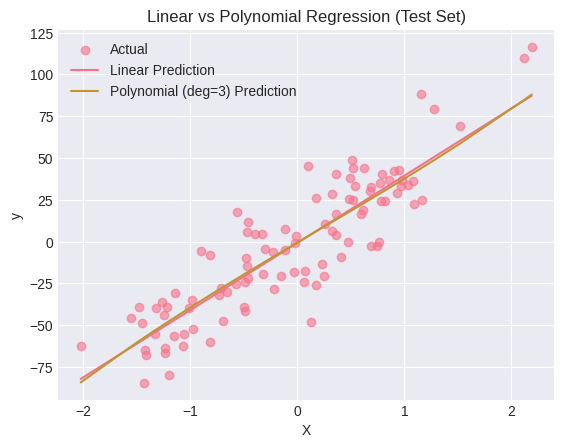


POST-LAB A: CROSS-VALIDATION (REGRESSION)
Linear CV R2: [0.78302815 0.73733331 0.78753507 0.80017575 0.73571796] Mean: 0.7687580466378864
Ridge  CV R2: [0.78303008 0.73685417 0.78781165 0.79999923 0.73603215] Mean: 0.768745455783099
Lasso  CV R2: [0.78303107 0.73694674 0.78775499 0.80003594 0.73596676] Mean: 0.7687470990277298
Poly3  CV R2: [0.78395446 0.73324651 0.79023866 0.80081061 0.72159083] Mean: 0.7659682131476027

POST-LAB B: LOGISTIC REGRESSION (DIFFERENT REGULARIZATION STRENGTHS)

--- AUC for Different C Values ---
C=0.01   AUC=0.9939
C=0.1    AUC=0.9966
C=1      AUC=0.9981
C=10     AUC=0.9963
C=100    AUC=0.9879


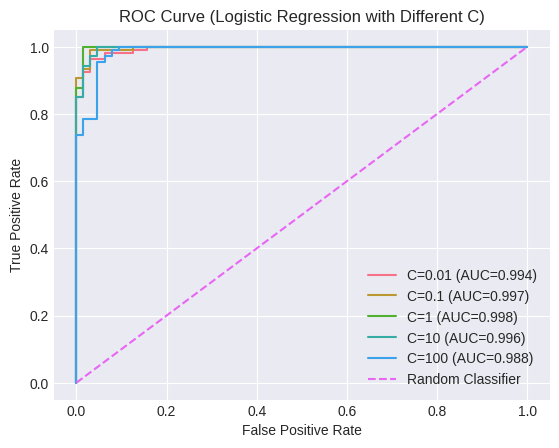


POST-LAB B: CROSS-VALIDATION (LOGISTIC REGRESSION)
Logistic Regression CV Accuracy: [0.97368421 0.98245614 0.96491228 0.99122807 0.97345133] Mean: 0.9771464058376029


In [2]:
# POST-LAB (EXP-4): Ridge & Lasso (different alpha), Polynomial Regression vs Linear,
# Logistic Regression (different regularization strengths), ROC + AUC, Cross-Validation

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, auc

# =========================================================
# POST-LAB A) REGRESSION EXTENSIONS
# =========================================================

# ---------------------------------------------------------
# 1) Ridge and Lasso Regression with Different Alpha Values
# ---------------------------------------------------------
# Title: Ridge and Lasso Regression with Multiple Alpha Values
X, y = make_regression(n_samples=400, n_features=1, noise=20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

alphas = [0.01, 0.1, 1, 10, 100]

print("=" * 70)
print("POST-LAB A: RIDGE & LASSO WITH DIFFERENT ALPHA VALUES")
print("=" * 70)

# Baseline Linear Regression (for comparison)
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)
print("\nLinear Regression -> Test MSE:", mean_squared_error(y_test, y_pred_lin), " Test R2:", r2_score(y_test, y_pred_lin))

# Ridge results
print("\n--- Ridge Results (alpha, MSE, R2) ---")
for a in alphas:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)
    print(f"alpha={a:<6} MSE={mean_squared_error(y_test, pred):.4f} R2={r2_score(y_test, pred):.4f}")

# Lasso results
print("\n--- Lasso Results (alpha, MSE, R2) ---")
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000, random_state=42)
    lasso.fit(X_train, y_train)
    pred = lasso.predict(X_test)
    print(f"alpha={a:<6} MSE={mean_squared_error(y_test, pred):.4f} R2={r2_score(y_test, pred):.4f}")


# ---------------------------------------------------------
# 2) Polynomial Regression and Compare with Linear Regression
# ---------------------------------------------------------
# Title: Polynomial Regression vs Linear Regression
degrees = [2, 3, 5]

print("\n" + "=" * 70)
print("POST-LAB A: POLYNOMIAL REGRESSION VS LINEAR REGRESSION")
print("=" * 70)

print("\n--- Polynomial Results (degree, MSE, R2) ---")
for d in degrees:
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lin", LinearRegression())
    ])
    poly_model.fit(X_train, y_train)
    pred = poly_model.predict(X_test)
    print(f"degree={d:<2} MSE={mean_squared_error(y_test, pred):.4f} R2={r2_score(y_test, pred):.4f}")

# Plot: Linear vs Polynomial (degree=3)
poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("lin", LinearRegression())
])
poly3.fit(X_train, y_train)

order = np.argsort(X_test.ravel())
X_test_sorted = X_test[order]
y_test_sorted = y_test[order]

plt.figure()
plt.scatter(X_test, y_test, alpha=0.6, label="Actual")
plt.plot(X_test_sorted, lin.predict(X_test_sorted), label="Linear Prediction")
plt.plot(X_test_sorted, poly3.predict(X_test_sorted), label="Polynomial (deg=3) Prediction")
plt.title("Linear vs Polynomial Regression (Test Set)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


# ---------------------------------------------------------
# 3) Cross-Validation for Regression Models
# ---------------------------------------------------------
# Title: Cross-Validation for Regression Models
print("\n" + "=" * 70)
print("POST-LAB A: CROSS-VALIDATION (REGRESSION)")
print("=" * 70)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv = cross_val_score(LinearRegression(), X, y, cv=cv, scoring="r2")
ridge_cv = cross_val_score(Ridge(alpha=1.0, random_state=42), X, y, cv=cv, scoring="r2")
lasso_cv = cross_val_score(Lasso(alpha=0.1, max_iter=10000, random_state=42), X, y, cv=cv, scoring="r2")
poly3_cv = cross_val_score(
    Pipeline([("poly", PolynomialFeatures(3, include_bias=False)), ("lin", LinearRegression())]),
    X, y, cv=cv, scoring="r2"
)

print("Linear CV R2:", lin_cv, "Mean:", lin_cv.mean())
print("Ridge  CV R2:", ridge_cv, "Mean:", ridge_cv.mean())
print("Lasso  CV R2:", lasso_cv, "Mean:", lasso_cv.mean())
print("Poly3  CV R2:", poly3_cv, "Mean:", poly3_cv.mean())


# =========================================================
# POST-LAB B) CLASSIFICATION EXTENSIONS
# =========================================================

# ---------------------------------------------------------
# 4) Logistic Regression with Different Regularization Strengths
# ---------------------------------------------------------
# Title: Logistic Regression with Different Regularization Strengths (C Values)
print("\n" + "=" * 70)
print("POST-LAB B: LOGISTIC REGRESSION (DIFFERENT REGULARIZATION STRENGTHS)")
print("=" * 70)

bc = load_breast_cancer()
Xc = bc.data
yc = bc.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.30, random_state=42, stratify=yc
)

# In sklearn: smaller C => stronger regularization
C_values = [0.01, 0.1, 1, 10, 100]

roc_results = []  # (C, fpr, tpr, auc_score)

for C in C_values:
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=C, max_iter=5000, random_state=42))
    ])
    clf.fit(Xc_train, yc_train)
    y_prob = clf.predict_proba(Xc_test)[:, 1]

    fpr, tpr, _ = roc_curve(yc_test, y_prob)
    auc_score = auc(fpr, tpr)
    roc_results.append((C, fpr, tpr, auc_score))

print("\n--- AUC for Different C Values ---")
for C, _, _, auc_score in roc_results:
    print(f"C={C:<6} AUC={auc_score:.4f}")


# ---------------------------------------------------------
# 5) Plot ROC Curve and Calculate AUC Score
# ---------------------------------------------------------
# Title: ROC Curves for Logistic Regression Models
plt.figure()
for C, fpr, tpr, auc_score in roc_results:
    plt.plot(fpr, tpr, label=f"C={C} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve (Logistic Regression with Different C)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 6) Cross-Validation for Logistic Regression Model
# ---------------------------------------------------------
# Title: Cross-Validation for Logistic Regression
print("\n" + "=" * 70)
print("POST-LAB B: CROSS-VALIDATION (LOGISTIC REGRESSION)")
print("=" * 70)

log_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=1.0, max_iter=5000, random_state=42))
])

log_cv_scores = cross_val_score(log_cv_model, Xc, yc, cv=cv, scoring="accuracy")
print("Logistic Regression CV Accuracy:", log_cv_scores, "Mean:", log_cv_scores.mean())